#Notebook 1 — Analise Exploratoria dos Dados (EDA)

Objetivo: entender a estrutura do dataset Reddit antes de qualquer decisao de preprocessamento ou modelagem.

**Perguntas que queremos responder:**
- Quais colunas existem e quais sao uteis?
- Qual e a distribuicao dos scores (target)?
- Como e a distribuicao do tamanho dos textos?
- Quantos valores nulos existem?
- Quais subreddits aparecem mais?
- O target esta balanceado com a mediana como threshold?

In [2]:
import sys

sys.path.insert(0, "..")

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

RAW_DATA_PATH = Path("../data/raw/reddit_data.csv")
print(f"Arquivo existe: {RAW_DATA_PATH.exists()}")

Arquivo existe: True


1. Carregar dados

In [3]:
df = pd.read_csv(RAW_DATA_PATH, low_memory=False)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (75140, 14)


,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,body,sentiment,score,domain,url,selftext,title
0,comment,hyyz6g8,2r97t,datasets,False,1646173750,https://old.reddit.com/r/datasets/comments/t45uk7/request_looking_for_a_dataset_that_i_can_use_t...,Spatial problem: Suitability of new locations for your favorite chain store. Use OpenStreetMap f...,0.0772,1,NaN,NaN,NaN,NaN
1,comment,hyyid7v,2r97t,datasets,False,1646167280,https://old.reddit.com/r/datasets/comments/sg9lv8/brainstorm_some_ideas_with_me_for_this_article...,Have you tried toying around with GDELT or Aliyn data?,0.0000,2,NaN,NaN,NaN,NaN
2,comment,hyxp1qp,2r97t,datasets,False,1646156018,https://old.reddit.com/r/datasets/comments/t44k10/a_datadump_of_more_than_120_internal_audits_fr...,"Damn random internet person of whom I know nothing, that's a fantastic offer. I will absolutely ...",-0.3851,3,NaN,NaN,NaN,NaN


2. Tipos de dados e valores nulos

In [4]:
print("--- Tipos ---")
print(df.dtypes)
print()
print("--- Valores nulos ---")
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
pd.DataFrame({"nulos": null_counts, "pct": null_pct}).sort_values(
    "nulos", ascending=False
)

--- Tipos ---
type               object
id                 object
subreddit.id       object
subreddit.name     object
subreddit.nsfw       bool
created_utc         int64
permalink          object
body               object
sentiment         float64
score               int64
domain             object
url                object
selftext           object
title              object
dtype: object

--- Valores nulos ---


,nulos,pct
url,70164,93.38
selftext,59824,79.62
domain,54848,72.99
title,54848,72.99
sentiment,27770,36.96
body,20294,27.01
type,0,0.00
id,0,0.00
subreddit.id,0,0.00
subreddit.name,0,0.00


3. Distribuicao do score (target)

count    75140.000000
mean         3.701650
std         10.836594
min        -65.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        849.000000
Name: score, dtype: float64

Mediana: 1.0
Mean: 3.70


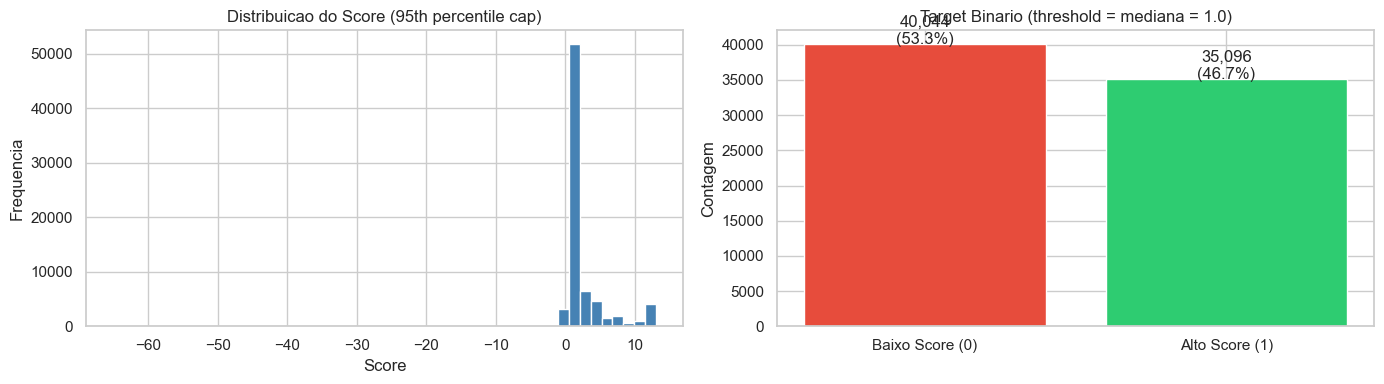


Balanceamento: 40,044 vs 35,096
Ratio: 1.14


In [5]:
if "score" in df.columns:
    print(df["score"].describe())
    print(f"\nMediana: {df['score'].median()}")
    print(f"Mean: {df['score'].mean():.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Distribuicao completa (log scale)
    axes[0].hist(
        df["score"].clip(upper=df["score"].quantile(0.95)),
        bins=50,
        color="steelblue",
        edgecolor="white",
    )
    axes[0].set_title("Distribuicao do Score (95th percentile cap)")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Frequencia")

    # Target binario usando mediana
    median_score = df["score"].median()
    y_binary = (df["score"] > median_score).astype(int)
    counts = y_binary.value_counts()
    axes[1].bar(
        ["Baixo Score (0)", "Alto Score (1)"],
        counts.values,
        color=["#e74c3c", "#2ecc71"],
    )
    axes[1].set_title(f"Target Binario (threshold = mediana = {median_score})")
    axes[1].set_ylabel("Contagem")
    for i, v in enumerate(counts.values):
        axes[1].text(i, v + 100, f"{v:,}\n({v / len(df) * 100:.1f}%)", ha="center")

    plt.tight_layout()
    plt.show()

    print(f"\nBalanceamento: {counts.values[0]:,} vs {counts.values[1]:,}")
    print(f"Ratio: {counts.values[0] / counts.values[1]:.2f}")
else:
    print("Coluna score nao encontrada.")

4. Analise da coluna de texto (body)

Coluna de texto usada: body

--- Comprimento em caracteres ---
count    75140.000000
mean       154.939752
std        315.021579
min          0.000000
25%          0.000000
50%         62.000000
75%        187.000000
max       9979.000000
Name: body, dtype: float64

--- Contagem de palavras ---
count    75140.000000
mean        23.130290
std         43.168192
min          0.000000
25%          0.000000
50%          9.000000
75%         29.000000
max       1290.000000
Name: body, dtype: float64


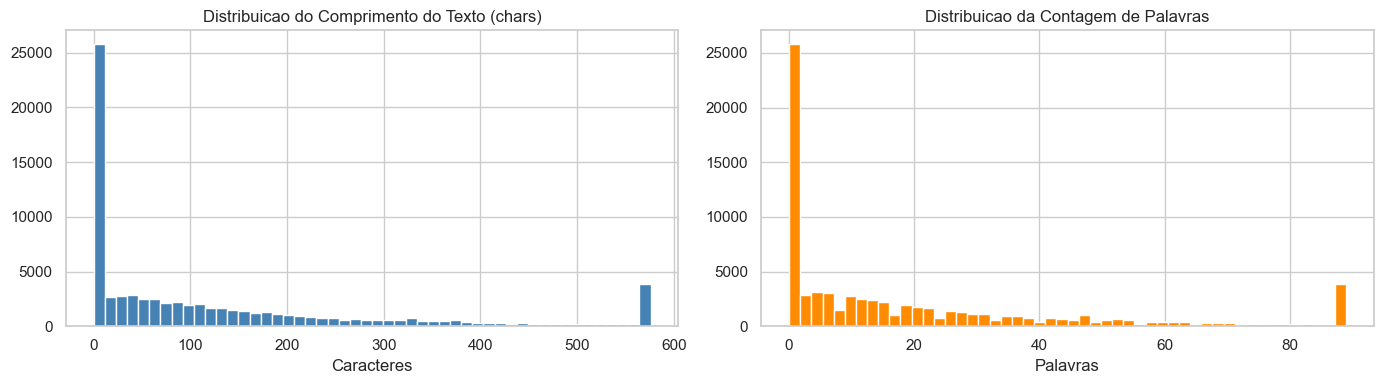


Textos vazios ou nulos: 20,294 (27.0%)


In [6]:
text_col = (
    "body" if "body" in df.columns else df.select_dtypes(include="object").columns[0]
)
print(f"Coluna de texto usada: {text_col}")

texts = df[text_col].fillna("")
text_lengths = texts.str.len()
word_counts = texts.str.split().str.len().fillna(0)

print("\n--- Comprimento em caracteres ---")
print(text_lengths.describe())

print("\n--- Contagem de palavras ---")
print(word_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    text_lengths.clip(upper=text_lengths.quantile(0.95)),
    bins=50,
    color="steelblue",
    edgecolor="white",
)
axes[0].set_title("Distribuicao do Comprimento do Texto (chars)")
axes[0].set_xlabel("Caracteres")

axes[1].hist(
    word_counts.clip(upper=word_counts.quantile(0.95)),
    bins=50,
    color="darkorange",
    edgecolor="white",
)
axes[1].set_title("Distribuicao da Contagem de Palavras")
axes[1].set_xlabel("Palavras")

plt.tight_layout()
plt.show()

# Textos vazios / nulos
empty = (texts.str.strip() == "") | (df[text_col].isnull())
print(f"\nTextos vazios ou nulos: {empty.sum():,} ({empty.mean() * 100:.1f}%)")

5. Top subreddits

In [7]:
sub_col = None
for c in ["subreddit", "subreddit_name", "sub"]:
    if c in df.columns:
        sub_col = c
        break

if sub_col:
    top_subs = df[sub_col].value_counts().head(20)
    plt.figure(figsize=(12, 5))
    top_subs.plot(kind="bar", color="steelblue", edgecolor="white")
    plt.title("Top 20 Subreddits")
    plt.ylabel("Contagem")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    print(f"Total de subreddits unicos: {df[sub_col].nunique():,}")
else:
    print("Coluna subreddit nao encontrada.")
    print(f"Colunas disponiveis: {list(df.columns)}")

Coluna subreddit nao encontrada.
Colunas disponiveis: ['type', 'id', 'subreddit.id', 'subreddit.name', 'subreddit.nsfw', 'created_utc', 'permalink', 'body', 'sentiment', 'score', 'domain', 'url', 'selftext', 'title']


In [8]:
sub_col

6. Score medio por subreddit (top 15)

In [9]:
if sub_col and "score" in df.columns:
    top15 = df[sub_col].value_counts().head(15).index
    score_by_sub = (
        df[df[sub_col].isin(top15)]
        .groupby(sub_col)["score"]
        .median()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 5))
    score_by_sub.plot(kind="bar", color="darkorange", edgecolor="white")
    plt.title("Score Mediano por Subreddit (Top 15)")
    plt.ylabel("Score Mediano")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

7. Amostras de texto por classe

In [10]:
if "score" in df.columns:
    median_score = df["score"].median()
    print("=== TEXTOS COM ALTO SCORE (acima da mediana) ===")
    high = df[df["score"] > median_score][text_col].dropna().head(3)
    for i, t in enumerate(high):
        print(f"\n[{i + 1}] {str(t)[:300]}")

    print("\n=== TEXTOS COM BAIXO SCORE (abaixo da mediana) ===")
    low = df[df["score"] <= median_score][text_col].dropna().head(3)
    for i, t in enumerate(low):
        print(f"\n[{i + 1}] {str(t)[:300]}")

=== TEXTOS COM ALTO SCORE (acima da mediana) ===

[1] Have you tried toying around with GDELT or Aliyn data?

[2] Damn random internet person of whom I know nothing, that's a fantastic offer. I will absolutely get in touch with you at a later date. I am struggling to see how I can take what I have learned so far and actually apply it to a job. I'm sure it is a struggle that every student contends with, the adde

[3] Ah nice one. Best of luck with the baby. If you are looking for an internship or anything message me in case I know anyone in the area you are interested in

=== TEXTOS COM BAIXO SCORE (abaixo da mediana) ===

[1] Spatial problem: Suitability of new locations for your favorite chain store. Use OpenStreetMap for the data.

[2] This page might be useful: [https://en.wikipedia.org/wiki/List\_of\_cities\_by\_elevation](https://en.wikipedia.org/wiki/List_of_cities_by_elevation)

You can import its tables with pandas:

```
import pandas as pd
wiki_url = 'https://en.wikipedia.org/

8. Conclusoes

Preencha apos rodar o notebook:

- **Target**: coluna `score` binarizada pela mediana → dataset balanceado? ____
- **Coluna de texto**: `body` com ___ % de valores nulos → precisa tratar nulos
- **Comprimento medio dos textos**: ___ palavras
- **Textos vazios**: ___ % → serao removidos no preprocessing
- **Parametro decidido**: threshold do target = mediana do score
- **Proximo passo**: notebook 02 para definir parametros de preprocessing